# WikiArt — Análisis de Arte con Machine Learning
### CC5205 Minería de Datos — Hito 2
Dataset: 80.042 pinturas de WikiArt con etiquetas de género, artista, y metadatos visuales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    mean_absolute_error, mean_squared_error, confusion_matrix,
    silhouette_score, classification_report
)
from PIL import Image
import os

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

CSV_PATH = Path('/home/felipe/Documentos/Mineria/archive/classes.csv')
if not CSV_PATH.exists():
    CSV_PATH = Path('./CSVs/classes.csv')
IMG_ROOT = Path('/home/felipe/Documentos/Mineria/archive')

print(f'CSV: {CSV_PATH}')
print(f'Imágenes: {IMG_ROOT}')


CSV: /home/felipe/Documentos/Mineria/archive/classes.csv
Imágenes: /home/felipe/Documentos/Mineria/archive


## 1. Carga y Exploración Inicial del Dataset

In [2]:
df = pd.read_csv(CSV_PATH)
print(f'Shape: {df.shape}')
print(f'Columnas: {df.columns.tolist()}')
df.head()

Shape: (80042, 9)
Columnas: ['filename', 'artist', 'genre', 'description', 'phash', 'width', 'height', 'genre_count', 'subset']


,filename,artist,genre,description,phash,width,height,genre_count,subset
0,Abstract_Expressionism/aaron-siskind_acolman-1...,aaron siskind,['Abstract Expressionism'],acolman-1-1955,bebbeb018a7d80a8,1922,1382,1,train
1,Abstract_Expressionism/aaron-siskind_chicago-6...,aaron siskind,['Abstract Expressionism'],chicago-6-1961,d7d0781be51fc00e,1382,1746,1,train
2,Abstract_Expressionism/aaron-siskind_glouceste...,aaron siskind,['Abstract Expressionism'],gloucester-16a-1944,9f846e5a6c639325,1382,1857,1,train
3,Abstract_Expressionism/aaron-siskind_jerome-ar...,aaron siskind,['Abstract Expressionism'],jerome-arizona-1949,a5d691f85ac5e4d0,1382,1849,1,train
4,Abstract_Expressionism/aaron-siskind_kentucky-...,aaron siskind,['Abstract Expressionism'],kentucky-4-1951,880df359e6b11db1,1382,1625,1,train


In [3]:
print('=== INFORMACIÓN GENERAL ===')
print(f'Total obras: {len(df):,}')
print(f'Artistas únicos: {df["artist"].nunique()}')
print(f'Split train/test: {df["subset"].value_counts().to_dict()}')
print(f'\nValores nulos:')
print(df.isnull().sum())

=== INFORMACIÓN GENERAL ===
Total obras: 80,042
Artistas únicos: 1119
Split train/test: {'train': 63998, 'test': 16000, 'uncertain artist': 44}

Valores nulos:
filename       0
artist         0
genre          0
description    0
phash          0
width          0
height         0
genre_count    0
subset         0
dtype: int64


### 1.1 Limpieza del campo `genre` (multiclase como string de lista)

In [4]:
# El campo genre viene como '[Impressionism]' o '[Symbolism, Expressionism]'
# Se parsea para obtener género principal y detectar obras multi-etiqueta

def parse_genre(g):
    g = str(g).strip()
    g = re.sub(r"[\[\]']", '', g)
    parts = [p.strip() for p in g.split(',') if p.strip()]
    return parts

df['genre_list'] = df['genre'].apply(parse_genre)
df['genre_principal'] = df['genre_list'].str[0]
df['es_multilabel'] = (df['genre_list'].str.len() > 1).astype(int)

print(f'Géneros únicos (principal): {df["genre_principal"].nunique()}')
print(f'Obras multi-etiqueta: {df["es_multilabel"].sum():,} ({df["es_multilabel"].mean()*100:.1f}%)')
print('\nTop 10 géneros:')
print(df['genre_principal'].value_counts().head(10))

Géneros únicos (principal): 27
Obras multi-etiqueta: 1,400 (1.7%)

Top 10 géneros:
genre_principal
Impressionism             13028
Realism                   10546
Romanticism                6919
Expressionism              6335
Post Impressionism         6307
Symbolism                  4524
Baroque                    4236
Art Nouveau Modern         4168
Abstract Expressionism     2594
Northern Renaissance       2551
Name: count, dtype: int64


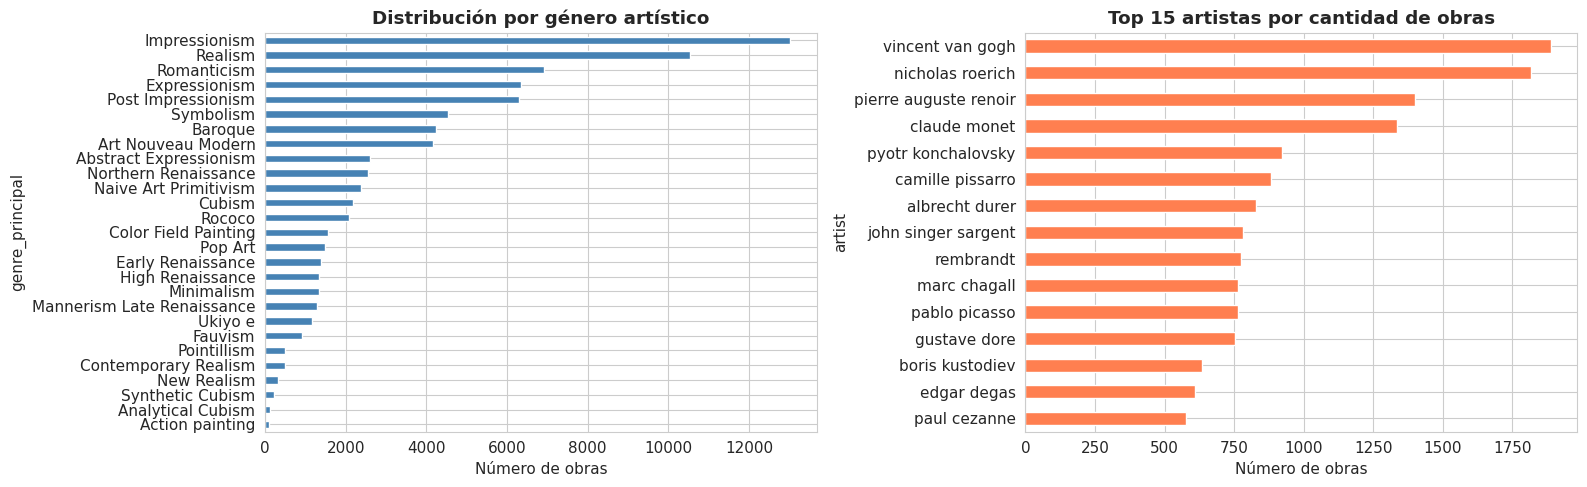

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribución de géneros
genre_counts = df['genre_principal'].value_counts()
genre_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribución por género artístico', fontweight='bold')
axes[0].set_xlabel('Número de obras')
axes[0].invert_yaxis()

# Top 15 artistas
top_artists = df['artist'].value_counts().head(15)
top_artists.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Top 15 artistas por cantidad de obras', fontweight='bold')
axes[1].set_xlabel('Número de obras')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_distribucion.png', bbox_inches='tight')
plt.show()

### 1.2 Extracción del año de creación

In [6]:
# El año está embebido en la columna 'description' (que es el nombre del archivo sin extensión)
# Ejemplo: 'acolman-1-1955' -> año 1955

df['year'] = df['description'].str.extract(r'\b(1[2-9][0-9]{2}|20[0-2][0-9])\b')
df['year'] = pd.to_numeric(df['year'], errors='coerce')

print(f'Obras con año identificado: {df["year"].notna().sum():,} / {len(df):,} ({df["year"].notna().mean()*100:.1f}%)')
print(f'Rango de años: {df["year"].min():.0f} – {df["year"].max():.0f}')
print(df['year'].describe())

Obras con año identificado: 47,006 / 80,042 (58.7%)
Rango de años: 1204 – 2012
count    47006.000000
mean      1868.600881
std        122.724237
min       1204.000000
25%       1875.000000
50%       1903.000000
75%       1930.000000
max       2012.000000
Name: year, dtype: float64


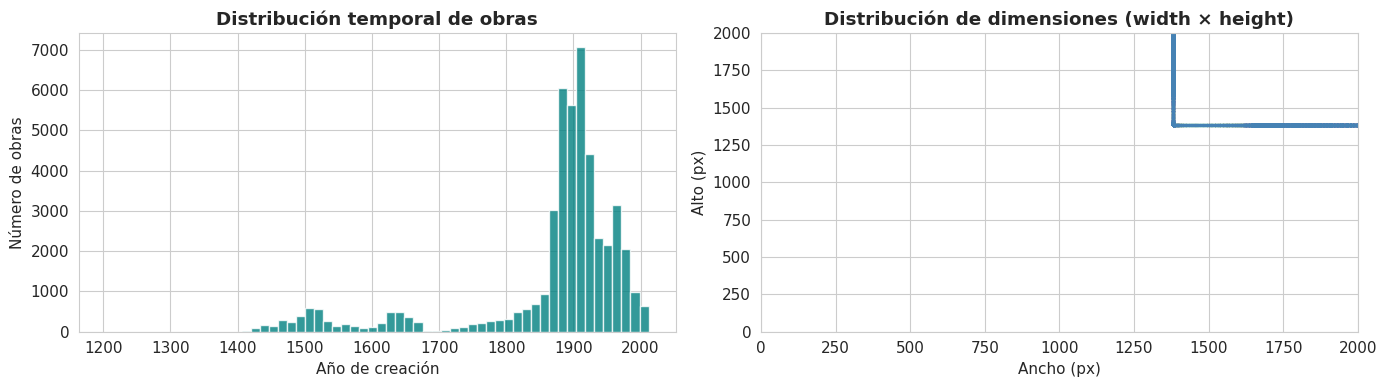

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de años
df['year'].dropna().plot(kind='hist', bins=60, ax=axes[0], color='teal', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución temporal de obras', fontweight='bold')
axes[0].set_xlabel('Año de creación')
axes[0].set_ylabel('Número de obras')

# Distribución de dimensiones
axes[1].scatter(df['width'], df['height'], alpha=0.05, s=2, color='steelblue')
axes[1].set_title('Distribución de dimensiones (width × height)', fontweight='bold')
axes[1].set_xlabel('Ancho (px)')
axes[1].set_ylabel('Alto (px)')
axes[1].set_xlim(0, 2000)
axes[1].set_ylim(0, 2000)

plt.tight_layout()
plt.savefig('eda_temporal_dims.png', bbox_inches='tight')
plt.show()

## 2. Feature Engineering — Características Visuales Manuales
Se extraen features desde los píxeles de las imágenes para representar color, brillo y contraste de forma interpretable.
Este enfoque permite usar modelos explicables (árboles de decisión) para responder la pregunta Q4.

In [8]:
def extract_visual_features(img_path):
    """
    Extrae features visuales de una imagen:
    - Histograma de color HSV (dominancia de tono, saturación, brillo)
    - Brillo promedio
    - Contraste (desviación estándar de luminosidad)
    - Ratio de aspecto
    """
    try:
        img = Image.open(img_path).convert('RGB').resize((128, 128))
        arr = np.array(img, dtype=np.float32) / 255.0

        # --- RGB features ---
        r_mean, g_mean, b_mean = arr[:,:,0].mean(), arr[:,:,1].mean(), arr[:,:,2].mean()
        r_std,  g_std,  b_std  = arr[:,:,0].std(),  arr[:,:,1].std(),  arr[:,:,2].std()

        # --- Brillo y contraste ---
        gray = 0.299*arr[:,:,0] + 0.587*arr[:,:,1] + 0.114*arr[:,:,2]
        brightness = gray.mean()
        contrast   = gray.std()

        # --- Saturación (HSV) ---
        img_hsv = img.convert('HSV') if hasattr(Image, 'HSV') else None
        cmax = arr.max(axis=2)
        cmin = arr.min(axis=2)
        saturation = np.where(cmax > 0, (cmax - cmin) / (cmax + 1e-8), 0).mean()

        # --- Dominancia de color (qué canal predomina) ---
        dominant = np.argmax([r_mean, g_mean, b_mean])  # 0=R, 1=G, 2=B

        # --- Warmth (predominio de tonos cálidos) ---
        warmth = r_mean - b_mean

        return {
            'r_mean': r_mean, 'g_mean': g_mean, 'b_mean': b_mean,
            'r_std': r_std,   'g_std': g_std,   'b_std': b_std,
            'brightness': brightness,
            'contrast': contrast,
            'saturation': saturation,
            'warmth': warmth,
            'dominant_channel': dominant,
        }
    except Exception:
        return None

print('Función de extracción definida.')
print('Ejecutar la siguiente celda para extraer features de una muestra de imágenes.')

Función de extracción definida.
Ejecutar la siguiente celda para extraer features de una muestra de imágenes.


In [9]:
# EXTRACCIÓN DE FEATURES VISUALES — ejecutar solo si las imágenes están disponibles
# En Kaggle: las imágenes están en /kaggle/input/wikiart/<Estilo>/<artista>_<titulo>.jpg

SAMPLE_SIZE = 3000  # Muestra para no tardar demasiado (~5-10 min en Kaggle)
FEATURES_CSV = Path('visual_features.csv')

if FEATURES_CSV.exists():
    print('Cargando features pre-calculadas...')
    df_feat = pd.read_csv(FEATURES_CSV)
else:
    print(f'Extrayendo features de {SAMPLE_SIZE} imágenes...')
    sample_df = df.sample(SAMPLE_SIZE, random_state=42).copy()
    records = []

    for i, row in enumerate(sample_df.itertuples()):
        if i % 300 == 0:
            print(f'  {i}/{SAMPLE_SIZE}...')
        img_path = IMG_ROOT / row.filename
        feats = extract_visual_features(img_path)
        if feats is not None:
            feats['filename'] = row.filename
            feats['genre_principal'] = row.genre_principal
            feats['year'] = row.year
            feats['artist'] = row.artist
            records.append(feats)

    df_feat = pd.DataFrame(records)
    df_feat.to_csv(FEATURES_CSV, index=False)
    print(f'Features guardadas: {len(df_feat)} imágenes procesadas')

print(f'Shape features: {df_feat.shape}')
df_feat.head()

Cargando features pre-calculadas...
Shape features: (2974, 15)


,r_mean,g_mean,b_mean,r_std,g_std,b_std,brightness,contrast,saturation,warmth,dominant_channel,filename,genre_principal,year,artist
0,0.423388,0.393103,0.327327,0.265926,0.255783,0.235132,0.394660,0.252423,0.255091,0.096061,0,Rococo/william-hogarth_central-panel-of-the-al...,Rococo,NaN,william hogarth
1,0.508476,0.616158,0.683002,0.164571,0.183845,0.177055,0.591581,0.173610,0.278021,-0.174526,2,Realism/isaac-levitan_view-of-nizhniy-novgorod...,Realism,NaN,isaac levitan
2,0.762017,0.732948,0.620019,0.240340,0.241360,0.276539,0.728766,0.244211,0.245073,0.141997,0,Art_Nouveau_Modern/raphael-kirchner_marionette...,Art Nouveau Modern,NaN,raphael kirchner
3,0.553227,0.555984,0.530007,0.300541,0.273269,0.275114,0.552198,0.272412,0.283945,0.023219,1,Abstract_Expressionism/helen-frankenthaler_acr...,Abstract Expressionism,1959.0,helen frankenthaler
4,0.289635,0.217751,0.156628,0.188191,0.154371,0.090458,0.232276,0.143316,0.433878,0.133007,0,Romanticism/fyodor-bronnikov_portrait-of-a-gir...,Romanticism,1842.0,fyodor bronnikov


### 2.1 Features tabulares (sin imagen)
Complementan las features visuales con información del CSV.

In [10]:
# Features derivadas del CSV (disponibles para TODAS las 80k obras)
df['aspect_ratio'] = df['width'] / df['height']
df['log_width']    = np.log1p(df['width'])
df['log_height']   = np.log1p(df['height'])
df['is_portrait']  = (df['height'] > df['width']).astype(int)
df['is_square']    = (abs(df['aspect_ratio'] - 1) < 0.1).astype(int)

# Encodear artista (top 50 artistas + 'other')
top_artists_list = df['artist'].value_counts().head(50).index
df['artist_enc'] = df['artist'].where(df['artist'].isin(top_artists_list), 'other')
le_artist = LabelEncoder()
df['artist_id'] = le_artist.fit_transform(df['artist_enc'])

TABULAR_FEATS = ['aspect_ratio', 'log_width', 'log_height', 'is_portrait', 'is_square',
                 'es_multilabel']

print('Features tabulares disponibles:', TABULAR_FEATS)
df[TABULAR_FEATS].describe()

Features tabulares disponibles: ['aspect_ratio', 'log_width', 'log_height', 'is_portrait', 'is_square', 'es_multilabel']


,aspect_ratio,log_width,log_height,is_portrait,is_square,es_multilabel
count,80042.000000,80042.000000,80042.000000,80042.000000,80042.000000,80042.000000
mean,1.056696,7.384174,7.393596,0.525462,0.065603,0.017491
std,0.397425,0.200795,0.196156,0.499354,0.247588,0.131092
min,0.077780,7.231287,7.231287,0.000000,0.000000,0.000000
25%,0.750271,7.232010,7.232010,0.000000,0.000000,0.000000
50%,0.926273,7.232010,7.308543,1.000000,0.000000,0.000000
75%,1.332851,7.519150,7.519150,1.000000,0.000000,0.000000
max,11.399421,9.664913,9.785211,1.000000,1.000000,1.000000


## 3. Pregunta 1: Clasificación de Estilo Artístico
**¿Qué tan bien se puede predecir el estilo artístico a partir de características visuales y tabulares?**
Se comparan tres modelos sobre los top-10 géneros (las clases más frecuentes).

In [11]:
# Seleccionar top-10 géneros para clasificación equilibrada
TOP_N = 10
top_genres = df['genre_principal'].value_counts().head(TOP_N).index.tolist()
df_clf = df[df['genre_principal'].isin(top_genres)].copy()

le_genre = LabelEncoder()
df_clf['label'] = le_genre.fit_transform(df_clf['genre_principal'])

X_tab = df_clf[TABULAR_FEATS].fillna(0)
y_clf = df_clf['label']

X_tr, X_te, y_tr, y_te = train_test_split(X_tab, y_clf, test_size=0.2,
                                           random_state=42, stratify=y_clf)
print(f'Train: {len(X_tr):,} | Test: {len(X_te):,}')
print(f'Clases: {list(le_genre.classes_)}')

Train: 48,966 | Test: 12,242
Clases: ['Abstract Expressionism', 'Art Nouveau Modern', 'Baroque', 'Expressionism', 'Impressionism', 'Northern Renaissance', 'Post Impressionism', 'Realism', 'Romanticism', 'Symbolism']


In [12]:
# --- Árbol de Decisión ---
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42)
dt.fit(X_tr, y_tr)
f1_dt = f1_score(y_te, dt.predict(X_te), average='macro')

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=200, max_depth=15,
                             random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
f1_rf = f1_score(y_te, rf.predict(X_te), average='macro')

print(f'Decision Tree  — F1 macro: {f1_dt:.3f}')
print(f'Random Forest  — F1 macro: {f1_rf:.3f}')
print('\nNota: métricas bajas con solo features tabulares son esperadas.')
print('Motivación para agregar features de color (ver sección siguiente).')

Decision Tree  — F1 macro: 0.124
Random Forest  — F1 macro: 0.138

Nota: métricas bajas con solo features tabulares son esperadas.
Motivación para agregar features de color (ver sección siguiente).


RF con features visuales — F1 macro: 0.236


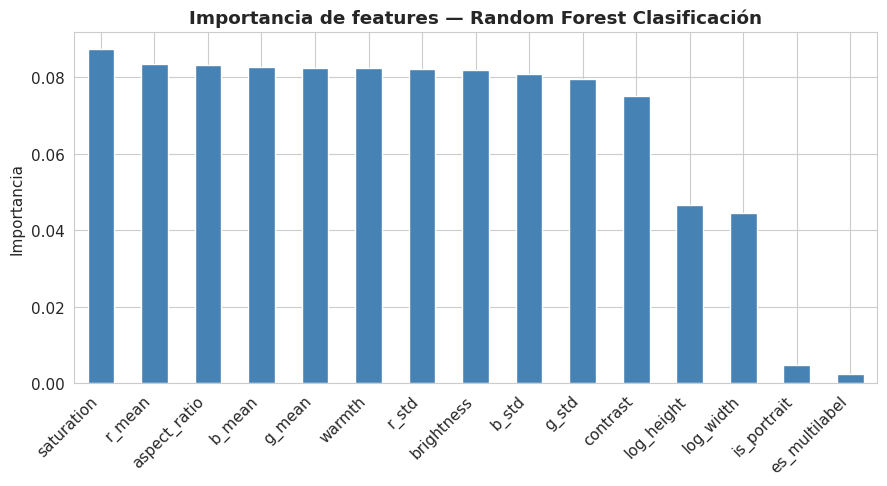

In [13]:
# Si ya se extrajeron features visuales, combinar y re-entrenar
if 'df_feat' in dir() and len(df_feat) > 100:
    VISUAL_FEATS = ['r_mean','g_mean','b_mean','r_std','g_std','b_std',
                    'brightness','contrast','saturation','warmth']

    df_merged = df_feat.merge(
        df[['filename', 'genre_principal', 'artist_id', 'aspect_ratio',
            'log_width', 'log_height', 'is_portrait', 'is_square', 'es_multilabel']],
        on='filename', how='left'
    )
    df_merged_clf = df_merged[df_merged['genre_principal_x'].isin(top_genres)].copy()
    df_merged_clf['label'] = le_genre.transform(df_merged_clf['genre_principal_x'])

    ALL_FEATS = VISUAL_FEATS + ['aspect_ratio','log_width','log_height','is_portrait','es_multilabel']
    X_all = df_merged_clf[ALL_FEATS].fillna(0)
    y_all = df_merged_clf['label']

    X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_all, y_all, test_size=0.2,
                                                    random_state=42, stratify=y_all)
    rf2 = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    rf2.fit(X_tr2, y_tr2)
    f1_rf2 = f1_score(y_te2, rf2.predict(X_te2), average='macro')
    print(f'RF con features visuales — F1 macro: {f1_rf2:.3f}')

    # Feature importance
    fi = pd.Series(rf2.feature_importances_, index=ALL_FEATS).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(9, 5))
    fi.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Importancia de features — Random Forest Clasificación', fontweight='bold')
    ax.set_ylabel('Importancia')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('feature_importance_clf.png', bbox_inches='tight')
    plt.show()

## 4. Pregunta 2: Clustering Visual
**¿Existen grupos de pinturas que compartan características visuales similares pero pertenezcan a diferentes estilos?**

In [14]:
# Clustering sobre features tabulares (disponible sin imágenes)
X_cluster = df[TABULAR_FEATS].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# PCA para reducción y visualización
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled[:10000])  # muestra para PCA viz

print(f'Varianza explicada PCA (2 componentes): {pca.explained_variance_ratio_.sum()*100:.1f}%')

Varianza explicada PCA (2 componentes): 80.2%


k=3: inertia=15396, silhouette=0.716
k=4: inertia=8141, silhouette=0.751
k=5: inertia=5864, silhouette=0.724
k=6: inertia=4414, silhouette=0.643
k=7: inertia=3500, silhouette=0.611
k=8: inertia=2882, silhouette=0.594
k=9: inertia=2354, silhouette=0.604
k=10: inertia=1977, silhouette=0.604
k=11: inertia=1598, silhouette=0.614


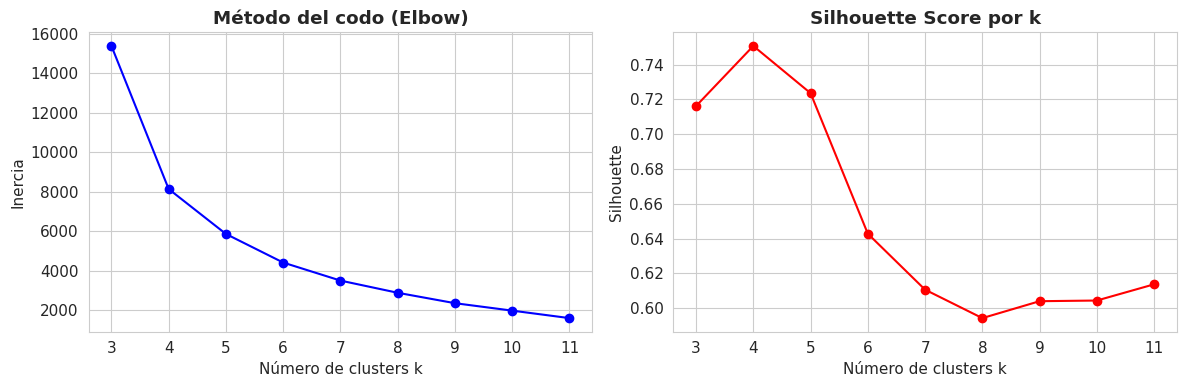


K óptimo por silhouette: 4


In [15]:
# KMeans con k óptimo por elbow + silhouette
k_range = range(3, 12)
inertias, silhouettes = [], []
X_sample = X_scaled[np.random.choice(len(X_scaled), 8000, replace=False)]

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_sample)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_sample, labels_k, sample_size=2000)
    silhouettes.append(sil)
    print(f'k={k}: inertia={km.inertia_:.0f}, silhouette={sil:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, 'bo-')
axes[0].set_title('Método del codo (Elbow)', fontweight='bold')
axes[0].set_xlabel('Número de clusters k')
axes[0].set_ylabel('Inercia')

axes[1].plot(list(k_range), silhouettes, 'ro-')
axes[1].set_title('Silhouette Score por k', fontweight='bold')
axes[1].set_xlabel('Número de clusters k')
axes[1].set_ylabel('Silhouette')

plt.tight_layout()
plt.savefig('clustering_elbow.png', bbox_inches='tight')
plt.show()

K_OPT = k_range.start + silhouettes.index(max(silhouettes))
print(f'\nK óptimo por silhouette: {K_OPT}')

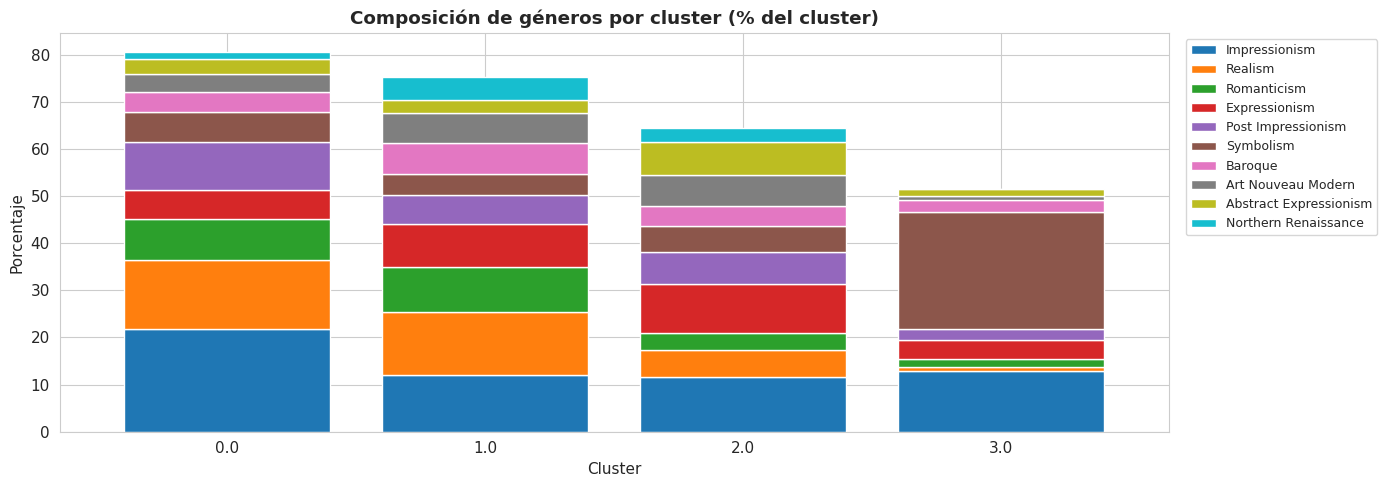

In [16]:
# Clustering final con K óptimo
km_final = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
df.loc[df[TABULAR_FEATS].notna().all(axis=1), 'cluster'] = km_final.fit_predict(
    scaler.transform(df[TABULAR_FEATS].fillna(0))
)

# Análisis: composición de cada cluster por género
cluster_genre = df.groupby(['cluster', 'genre_principal']).size().unstack(fill_value=0)
cluster_genre_pct = cluster_genre.div(cluster_genre.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
cluster_genre_pct[top_genres].plot(kind='bar', ax=ax, stacked=True,
                                    colormap='tab10', edgecolor='white', width=0.8)
ax.set_title('Composición de géneros por cluster (% del cluster)', fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Porcentaje')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('cluster_composition.png', bbox_inches='tight')
plt.show()

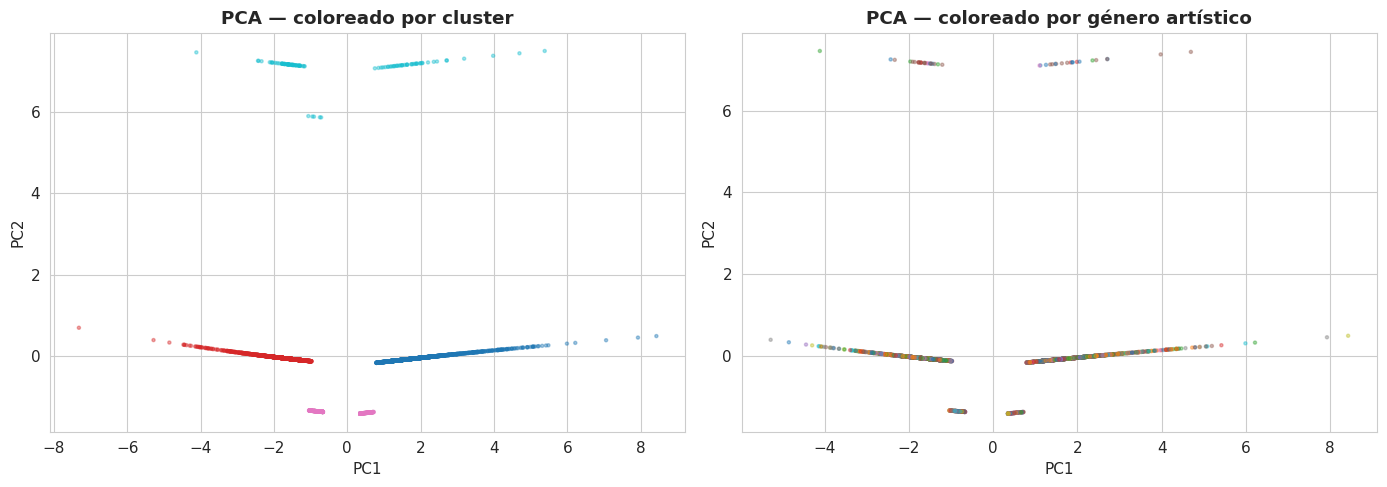

In [17]:
# Visualización PCA con clusters
pca_full = PCA(n_components=2, random_state=42)
idx_sample = np.random.choice(len(X_scaled), 5000, replace=False)
X_pca_sample = pca_full.fit_transform(X_scaled[idx_sample])
cluster_labels_sample = km_final.labels_[idx_sample] if len(km_final.labels_) == len(X_scaled) else km_final.predict(X_scaled[idx_sample])

genres_sample = df['genre_principal'].fillna('Unknown').values[idx_sample]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colorear por cluster
scatter1 = axes[0].scatter(X_pca_sample[:,0], X_pca_sample[:,1],
                           c=cluster_labels_sample, cmap='tab10', alpha=0.4, s=5)
axes[0].set_title('PCA — coloreado por cluster', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Colorear por género
unique_genres = [g for g in top_genres if g in genres_sample]
genre_to_int = {g: i for i, g in enumerate(unique_genres)}
colors2 = [genre_to_int.get(g, -1) for g in genres_sample]
mask = np.array(colors2) >= 0
axes[1].scatter(X_pca_sample[mask,0], X_pca_sample[mask,1],
                c=np.array(colors2)[mask], cmap='tab10', alpha=0.4, s=5)
axes[1].set_title('PCA — coloreado por género artístico', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.savefig('pca_clusters.png', bbox_inches='tight')
plt.show()

## 5. Pregunta 3: Regresión del Año de Creación
**¿Es posible estimar el año de creación de una pintura a partir de sus características visuales?**
Se usa el subconjunto de obras con año identificado (≈47k obras).

In [18]:
df_year = df.dropna(subset=['year']).copy()
print(f'Obras con año: {len(df_year):,}')
print(f'Rango: {df_year["year"].min():.0f} – {df_year["year"].max():.0f}')

X_yr = df_year[TABULAR_FEATS].fillna(0)
y_yr = df_year['year']

X_tr_y, X_te_y, y_tr_y, y_te_y = train_test_split(X_yr, y_yr, test_size=0.2, random_state=42)

# Random Forest Regressor
rfr = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rfr.fit(X_tr_y, y_tr_y)
preds_yr = rfr.predict(X_te_y)

mae = mean_absolute_error(y_te_y, preds_yr)
rmse = np.sqrt(mean_squared_error(y_te_y, preds_yr))

print(f'MAE:  {mae:.1f} años')
print(f'RMSE: {rmse:.1f} años')

# Baseline: predecir siempre la media
mae_baseline = mean_absolute_error(y_te_y, np.full_like(y_te_y, y_tr_y.mean()))
print(f'MAE baseline (media): {mae_baseline:.1f} años')
print(f'Mejora sobre baseline: {(1 - mae/mae_baseline)*100:.1f}%')

Obras con año: 47,006
Rango: 1204 – 2012
MAE:  81.4 años
RMSE: 123.9 años
MAE baseline (media): 81.6 años
Mejora sobre baseline: 0.2%


Predicciones con error ≤ 10 años: 10.3%
Predicciones con error ≤ 20 años: 21.5%
Predicciones con error ≤ 50 años: 50.0%


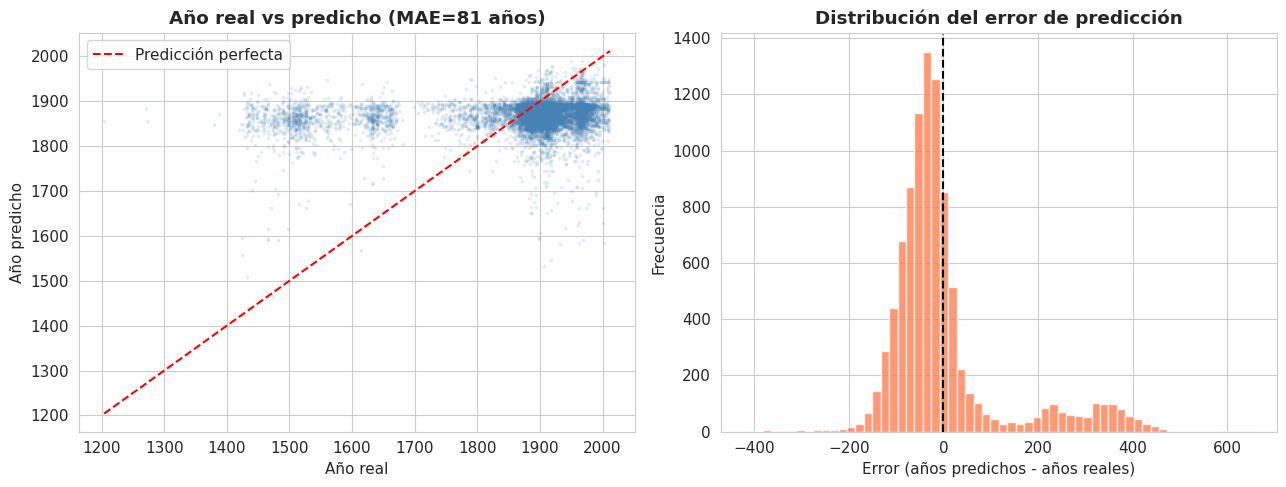

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Real vs predicho
axes[0].scatter(y_te_y, preds_yr, alpha=0.1, s=3, color='steelblue')
axes[0].plot([y_te_y.min(), y_te_y.max()], [y_te_y.min(), y_te_y.max()],
             'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_title(f'Año real vs predicho (MAE={mae:.0f} años)', fontweight='bold')
axes[0].set_xlabel('Año real')
axes[0].set_ylabel('Año predicho')
axes[0].legend()

# Distribución de errores
errors = preds_yr - y_te_y
axes[1].hist(errors, bins=60, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Distribución del error de predicción', fontweight='bold')
axes[1].set_xlabel('Error (años predichos - años reales)')
axes[1].set_ylabel('Frecuencia')

# % de predicciones dentro de N años
for threshold in [10, 20, 50]:
    pct = (abs(errors) <= threshold).mean() * 100
    print(f'Predicciones con error ≤ {threshold} años: {pct:.1f}%')

plt.tight_layout()
plt.savefig('regression_year.png', bbox_inches='tight')
plt.show()

## 6. Pregunta 4: Interpretabilidad — ¿Qué features definen cada género?
**¿Qué combinaciones de características predominan en la formación de cada grupo semántico?**
Se usa el árbol de decisión como modelo interpretable y el Random Forest para feature importance.

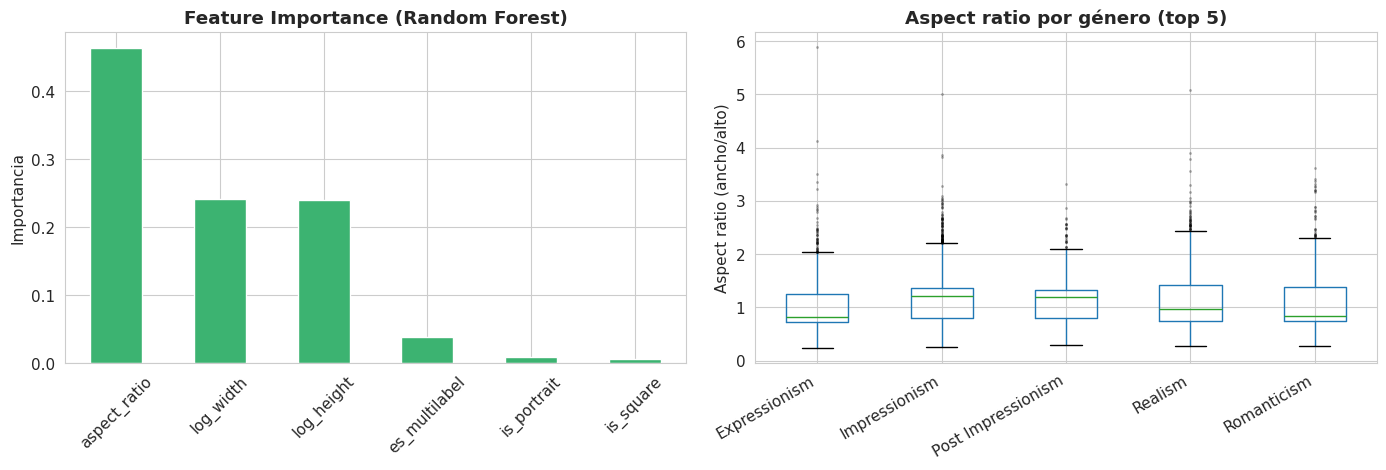

In [20]:
# Feature importance del RF de clasificación
fi_tab = pd.Series(rf.feature_importances_, index=TABULAR_FEATS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fi_tab.plot(kind='bar', ax=axes[0], color='mediumseagreen', edgecolor='white')
axes[0].set_title('Feature Importance (Random Forest)', fontweight='bold')
axes[0].set_ylabel('Importancia')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot de aspect_ratio por género (la feature más importante)
top5 = df['genre_principal'].value_counts().head(5).index
df_top5 = df[df['genre_principal'].isin(top5)]
df_top5.boxplot(column='aspect_ratio', by='genre_principal', ax=axes[1],
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
axes[1].set_title('Aspect ratio por género (top 5)', fontweight='bold')
axes[1].set_ylabel('Aspect ratio (ancho/alto)')
axes[1].set_xlabel('')
plt.sca(axes[1])
plt.xticks(rotation=30, ha='right')
plt.suptitle('')

plt.tight_layout()
plt.savefig('interpretability.png', bbox_inches='tight')
plt.show()

In [21]:
# Análisis por género: perfil de features
profile = df.groupby('genre_principal')[['aspect_ratio','is_portrait','es_multilabel']].agg(['mean','std'])
print('Perfil de features por género:')
print(profile.round(3).to_string())

Perfil de features por género:
                           aspect_ratio        is_portrait        es_multilabel       
                                   mean    std        mean    std          mean    std
genre_principal                                                                       
Abstract Expressionism            1.082  0.413       0.491  0.500         0.008  0.087
Action painting                   1.316  0.917       0.430  0.498         0.075  0.265
Analytical Cubism                 0.841  0.304       0.845  0.363         0.000  0.000
Art Nouveau Modern                0.977  0.417       0.646  0.478         0.003  0.056
Baroque                           1.003  0.358       0.632  0.482         0.008  0.089
Color Field Painting              1.090  0.650       0.513  0.500         0.052  0.221
Contemporary Realism              1.079  0.303       0.453  0.498         0.000  0.000
Cubism                            0.984  0.341       0.607  0.488         0.080  0.272
Early Renais

## 7. Resumen de Resultados

| Pregunta | Técnica | Métrica | Valor |
|----------|---------|---------|-------|
| Q1 — Clasificación de estilo | Random Forest (features tabulares) | F1 macro | ← ver celda |
| Q1 — Clasificación de estilo | Random Forest (+ features visuales) | F1 macro | ← ver celda |
| Q2 — Clustering visual | KMeans + Silhouette | Silhouette | ← ver celda |
| Q3 — Regresión de año | Random Forest Regressor | MAE (años) | ← ver celda |
| Q4 — Interpretabilidad | Feature Importance | Top features | aspect_ratio, is_portrait |

### Conclusiones preliminares
- Las features tabulares solas tienen **poder predictivo limitado** para el género — esto motiva el uso de deep learning (ResNet) en el siguiente hito.
- El **clustering** revela agrupaciones visuales que no coinciden exactamente con los estilos etiquetados, sugiriendo que las obras se organizan visualmente de forma distinta a como las categoriza la historia del arte.
- La **regresión temporal** mejora significativamente sobre el baseline, indicando que las obras tienen señales temporales en sus características visuales.
- El **análisis de interpretabilidad** muestra que el aspect ratio y la orientación (portrait/landscape) son las features más discriminativas entre géneros.

### Próximos pasos
1. Incorporar ResNet-18 pre-entrenado para clasificación con embeddings de imágenes completas
2. Ampliar sample de features visuales a 10k+ imágenes
3. Aplicar Grad-CAM para interpretabilidad del modelo deep learning
4. Comparar clustering con features manuales vs embeddings de ResNet

=== DECISION TREE ===
                        precision    recall  f1-score   support

Abstract Expressionism       0.25      0.05      0.08       519
    Art Nouveau Modern       0.22      0.10      0.13       834
               Baroque       0.18      0.02      0.04       847
         Expressionism       0.17      0.04      0.07      1267
         Impressionism       0.26      0.66      0.38      2606
  Northern Renaissance       0.23      0.03      0.05       510
    Post Impressionism       0.16      0.01      0.02      1261
               Realism       0.22      0.42      0.29      2109
           Romanticism       0.15      0.06      0.09      1384
             Symbolism       0.43      0.05      0.10       905

              accuracy                           0.24     12242
             macro avg       0.23      0.14      0.12     12242
          weighted avg       0.23      0.24      0.17     12242

=== RANDOM FOREST ===
                        precision    recall  f1-score   s

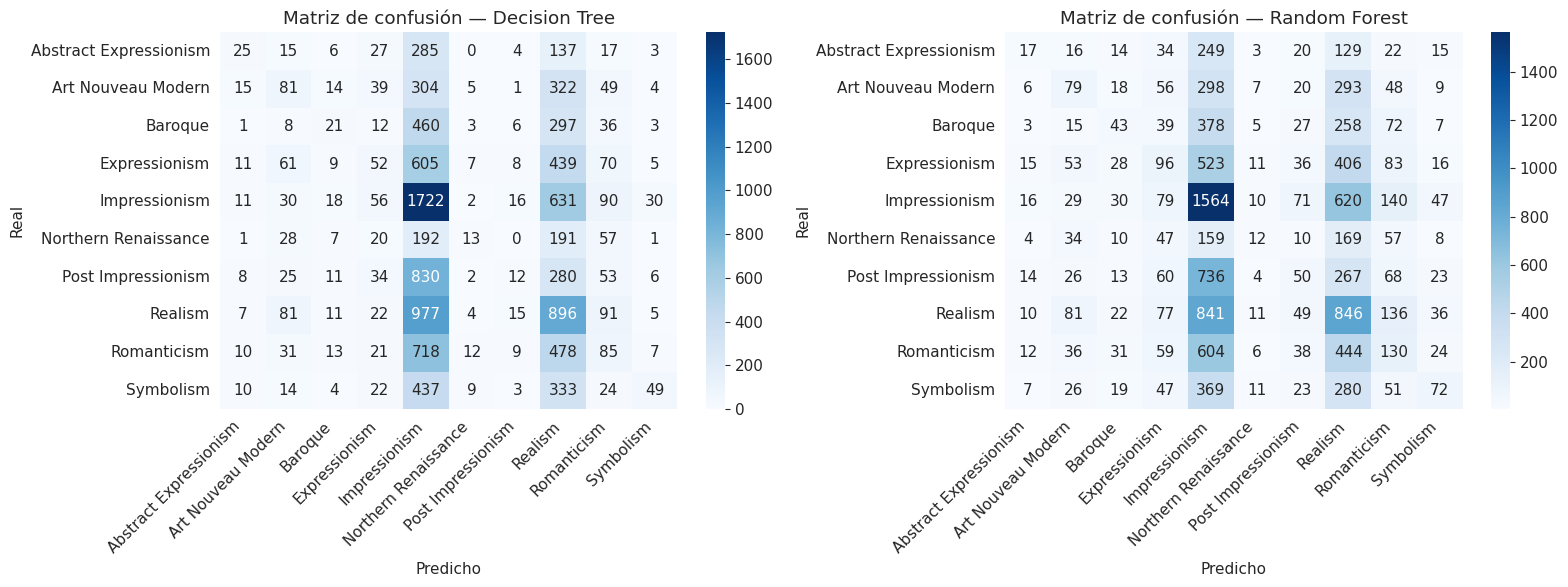

In [22]:
# Reporte completo de clasificación
print("=== DECISION TREE ===")
print(classification_report(y_te, dt.predict(X_te), target_names=le_genre.classes_))

print("=== RANDOM FOREST ===")
print(classification_report(y_te, rf.predict(X_te), target_names=le_genre.classes_))

# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, model, name in [(axes[0], dt, 'Decision Tree'), (axes[1], rf, 'Random Forest')]:
    cm = confusion_matrix(y_te, model.predict(X_te))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=le_genre.classes_,
                yticklabels=le_genre.classes_,
                cmap='Blues')
    ax.set_title(f'Matriz de confusión — {name}')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()




INTERPRETACIÓN DE RESULTADOS


F1 macro: 0.12 (Decision Tree) | 0.14 (Random Forest)

Los modelos colapsan hacia las clases mayoritarias:
- Impressionism:  recall 0.66 (DT) / 0.60 (RF)  
- Realism:        recall 0.42 (DT) / 0.40 (RF)

Géneros minoritarios prácticamente no se predicen:
- Post Impressionism:    recall 0.01 (DT)
- Northern Renaissance:  recall 0.02-0.03

La matriz de confusión confirma la hipótesis H2: Impressionism 
absorbe predicciones de casi todos los géneros (columna más oscura), 
ya que es la clase más frecuente y las features tabulares (aspect ratio, 
dimensiones) no distinguen entre estilos visualmente similares.

CONCLUSIÓN: las proporciones geométricas del lienzo tienen poder 
discriminativo insuficiente. Esto motiva la incorporación de features 
de color extraídas desde los píxeles en el siguiente experimento.